In [1]:
import numpy as np 
from belief_dynamics_learning.world2d import World2D

%load_ext autoreload
%autoreload 2

In [2]:
num_particles = 100
dt=0.1

# object properties 
dim_object = np.array([0.067, 0.14])
qo_gt = np.array([0, 1, 0]) # ground truth object pose
sigma_pos = 0.06 # standard deviation of position noise

# robot properties
qr_0 = np.array([0, 0.7])
r_robot = 0.05


0


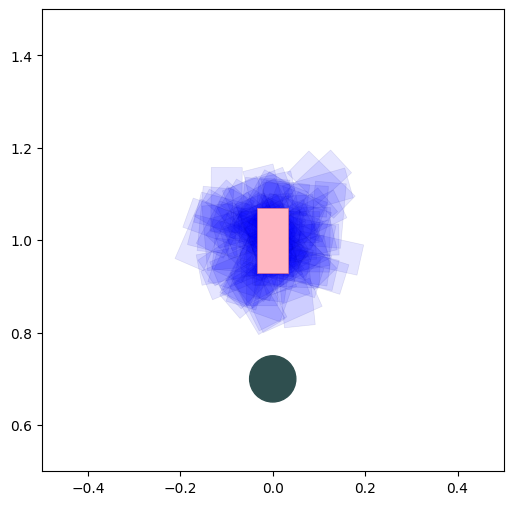

In [3]:
world = World2D(num_particles, qo_gt, dim_object, sigma_pos, 
                qr_0, r_robot, dt)
world.plot_belief()

New ground truth pose:  [0.17050962 1.34359292 1.98951227]
New robot pose:  [0.08756011 1.31598567]
Keeping indices: [-9, 14]


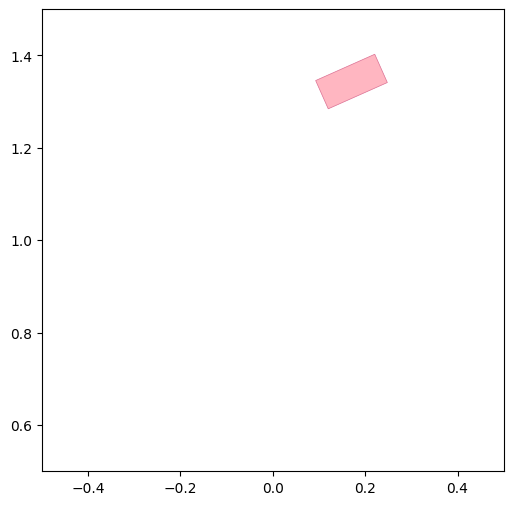

In [22]:
world.sample_gt_object_pose()
world.sample_robot_pose()
q_r_hist, o_hist, a_hist = world.rollout(100, world.qo_gt.copy())

# only keep bits of sequence around positive contact measurements 

contact_idx = np.where(o_hist==1)[0]
if len(contact_idx) == 0:
    print('No contact detected')
else:
    min_idx = np.min(contact_idx)
    max_idx = np.max(contact_idx)
    buffer_lb = np.min([min_idx, 10])
    buffer_ub = np.min([len(o_hist)-max_idx, 10])
    keep_idx = [min_idx-buffer_lb, max_idx+buffer_ub]
    print('Keeping indices:', keep_idx)
    q_r_hist = q_r_hist[keep_idx[0]:keep_idx[1]]
    o_hist = o_hist[keep_idx[0]:keep_idx[1]]
    world.plot_rollout(q_r_hist, o_hist)